# Carga de datos

Se carga el dataset del Titanic para comenzar con el análisis.

In [43]:
import pandas as pd
datos = pd.read_csv("Titanic-Dataset.csv")

In [44]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploración inicial de los datos

Se revisa la estructura del dataset, tipos de datos y estadísticas generales

In [45]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Análisis de la variable objetivo

Se visualiza la cantidad de personas que sobrevivieron y las que no sobrevivieron.

<Axes: xlabel='Survived', ylabel='count'>

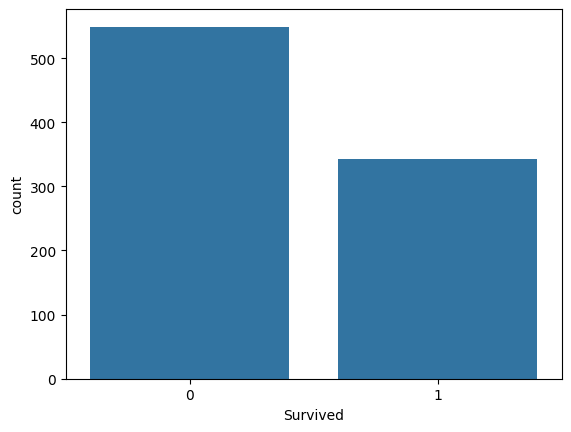

In [46]:
import seaborn as sb
sb.countplot(x='Survived',data=datos)

# Análisis por género

Se analiza la relación entre el género y la supervivencia de los pasajeros.

<Axes: xlabel='Survived', ylabel='count'>

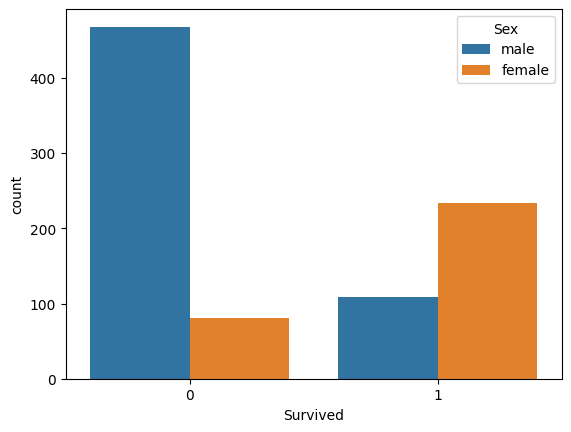

In [47]:
import seaborn as sb
sb.countplot(x='Survived',data=datos, hue='Sex')

# Identificación de valores nulos

Se identifican los valores faltantes dentro del dataset.

In [48]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Análisis de la edad

Se analiza la distribución de la edad de los pasajeros mediante un gráfico.

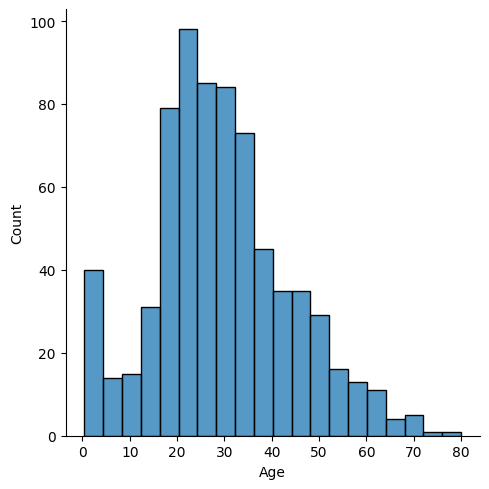

In [49]:
sb.displot(x ="Age", data=datos)

In [50]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [51]:
datos["Age"].mean()

np.float64(29.69911764705882)

# Limpieza de datos: Edad

Se reemplazan los valores nulos de la columna Age con el promedio de la misma.

In [52]:
datos["Age"].fillna(datos["Age"].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [53]:
datos["Age"] = datos["Age"].fillna(datos["Age"].mean())

In [54]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [55]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Eliminación de columnas con muchos valores nulos

Se elimina la columna Cabin debido a la gran cantidad de valores faltantes.

In [56]:
datos = datos.drop(["Cabin"], axis=1)

In [57]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [58]:
datos = datos.dropna()

In [59]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


# Limpieza de la variable Embarked

Se revisan los valores de la columna Embarked y se eliminan los registros con valores nulos.

In [60]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

# Conversión de variable categórica: Sex

Se convierte la variable Sex en valores numéricos mediante One Hot Encoding.

In [61]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

In [62]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

# Análisis de Embarked

Se analiza la relación entre el puerto de embarque y la supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

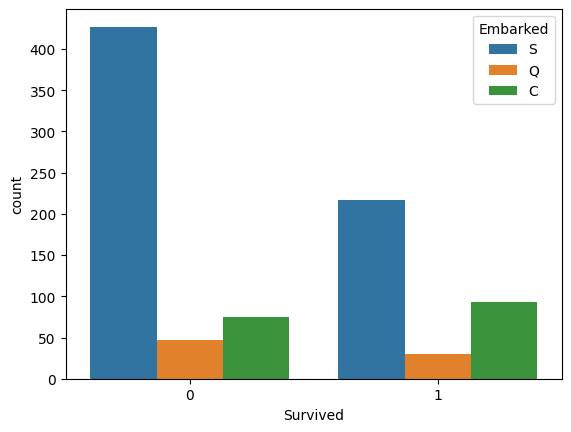

In [63]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

In [64]:
datos.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male
0,0,3,22.0,1,0,7.2500,S,True
1,1,1,38.0,1,0,71.2833,C,False
2,1,3,26.0,0,0,7.9250,S,False
3,1,1,35.0,1,0,53.1000,S,False
4,0,3,35.0,0,0,8.0500,S,True


# Conversión de variable categórica: Embarked

Se transforma la variable Embarked en variables numéricas.

In [65]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

In [66]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

# Matriz de correlación

Se visualiza la relación entre las variables mediante un mapa de calor.

<Axes: >

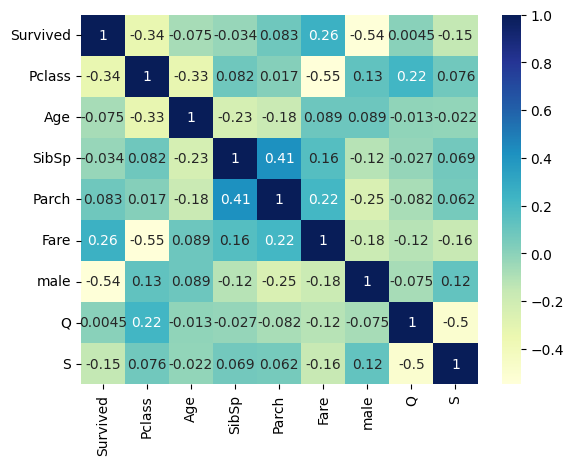

In [67]:
sb.heatmap(datos.corr(), annot=True, cmap='YlGnBu')

# Análisis por clase social

Se analiza la relación entre la clase del pasajero y la supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

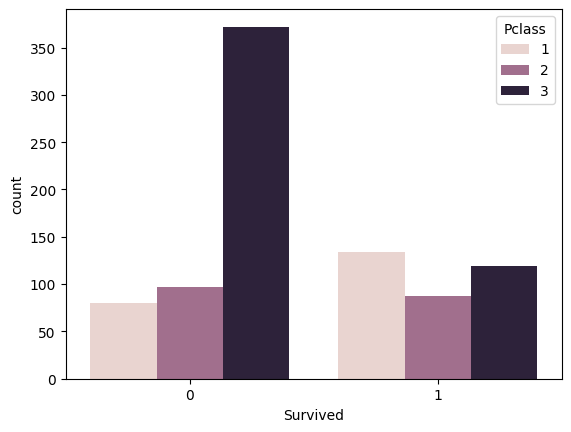

In [68]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

# Definición de variables

Se separan las variables independientes (X) y la variable dependiente (Y).

In [69]:
X = datos.drop(["Survived"], axis=1)
Y = datos["Survived"]

# División de datos

Se dividen los datos en entrenamiento y prueba.

In [70]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, Y, test_size=.2)

## Modelo de Árbol de Decisión

Se entrena un modelo de Árbol de Decisión, el cual permite clasificar datos mediante reglas basadas en condiciones.

In [70]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=50)
modelo.fit(X_ent, y_ent)

## Predicciones

Se realizan predicciones utilizando el conjunto de prueba para evaluar el desempeño del modelo.

In [ ]:
predicciones = modelo.predict(X_pru)

# Evaluación del modelo

Se calcula la precisión del modelo.

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.7640449438202247

## Optimización del modelo

Se evalúa el rendimiento del modelo variando la profundidad máxima del árbol (max_depth), con el objetivo de encontrar el valor que proporcione la mejor exactitud sin sobreajuste.

In [73]:
from sklearn.tree import DecisionTreeClassifier
resultados = []
for i in range (1, 15):
  modelo = DecisionTreeClassifier(max_depth=i)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(X_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print (f"Resultado para {i}: {exactitud}")
  resultados.append(exactitud)

Resultado para 1: 0.8202247191011236
Resultado para 2: 0.8033707865168539
Resultado para 3: 0.848314606741573
Resultado para 4: 0.848314606741573
Resultado para 5: 0.7752808988764045
Resultado para 6: 0.8370786516853933
Resultado para 7: 0.8089887640449438
Resultado para 8: 0.8033707865168539
Resultado para 9: 0.7584269662921348
Resultado para 10: 0.7808988764044944
Resultado para 11: 0.7640449438202247
Resultado para 12: 0.7415730337078652
Resultado para 13: 0.7415730337078652
Resultado para 14: 0.7303370786516854


## Visualización de resultados

Se grafica la exactitud obtenida para cada valor de profundidad del árbol, lo que permite identificar visualmente el mejor modelo.

<Axes: >

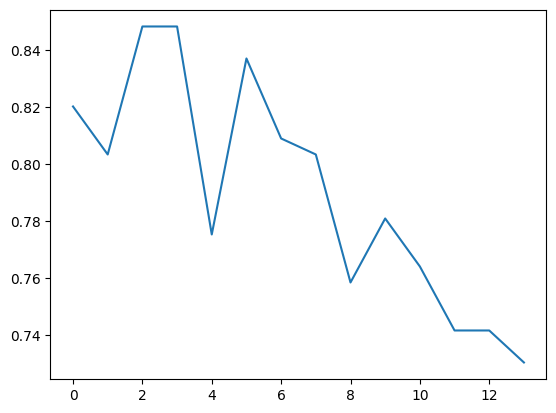

In [74]:
sb.lineplot(data = resultados)

In [ ]:
modelo = DecisionTreeClassifier(max_depth=4)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)
exactitud = accuracy_score(y_pru, predicciones)

# Reporte de clasificación

Se muestran métricas como precisión, recall y F1-score.

In [76]:
from sklearn.metrics import classification_report
print (classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80       129
           1       0.51      0.71      0.59        49

    accuracy                           0.73       178
   macro avg       0.69      0.73      0.70       178
weighted avg       0.77      0.73      0.74       178



## Matriz de confusión (evaluación inicial)

Se genera la matriz de confusión para analizar el número de predicciones correctas e incorrectas del modelo.

In [77]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: si"])

,Pred: No,Pred: Si
Real: No,95,34
Real: si,14,35


In [78]:
X.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q', 'S'], dtype='object')

## Visualización del árbol de decisión

Se representa gráficamente el árbol de decisión generado, mostrando las reglas utilizadas para clasificar a los pasajeros.

[Text(0.31799810332369943, 0.9666666666666667, 'male <= 0.5\n0.484\n711\n[420, 291]\nMurió'),
 Text(0.17064065510597304, 0.9, 'Pclass <= 2.5\n0.362\n253\n[60, 193]\nVivió'),
 Text(0.24431937921483624, 0.9333333333333333, 'True  '),
 Text(0.057803468208092484, 0.8333333333333334, 'Fare <= 13.25\n0.082\n140\n[6, 134]\nVivió'),
 Text(0.030828516377649325, 0.7666666666666667, 'Age <= 53.5\n0.266\n19\n[3, 16]\nVivió'),
 Text(0.023121387283236993, 0.7, 'Fare <= 12.825\n0.198\n18\n[2, 16]\nVivió'),
 Text(0.015414258188824663, 0.6333333333333333, '0.0\n9\n[0, 9]\nVivió'),
 Text(0.030828516377649325, 0.6333333333333333, 'Age <= 37.0\n0.346\n9\n[2, 7]\nVivió'),
 Text(0.023121387283236993, 0.5666666666666667, 'Age <= 26.0\n0.219\n8\n[1, 7]\nVivió'),
 Text(0.015414258188824663, 0.5, 'Parch <= 1.0\n0.5\n2\n[1, 1]\nMurió'),
 Text(0.007707129094412331, 0.43333333333333335, '0.0\n1\n[1, 0]\nMurió'),
 Text(0.023121387283236993, 0.43333333333333335, '0.0\n1\n[0, 1]\nVivió'),
 Text(0.030828516377649325, 

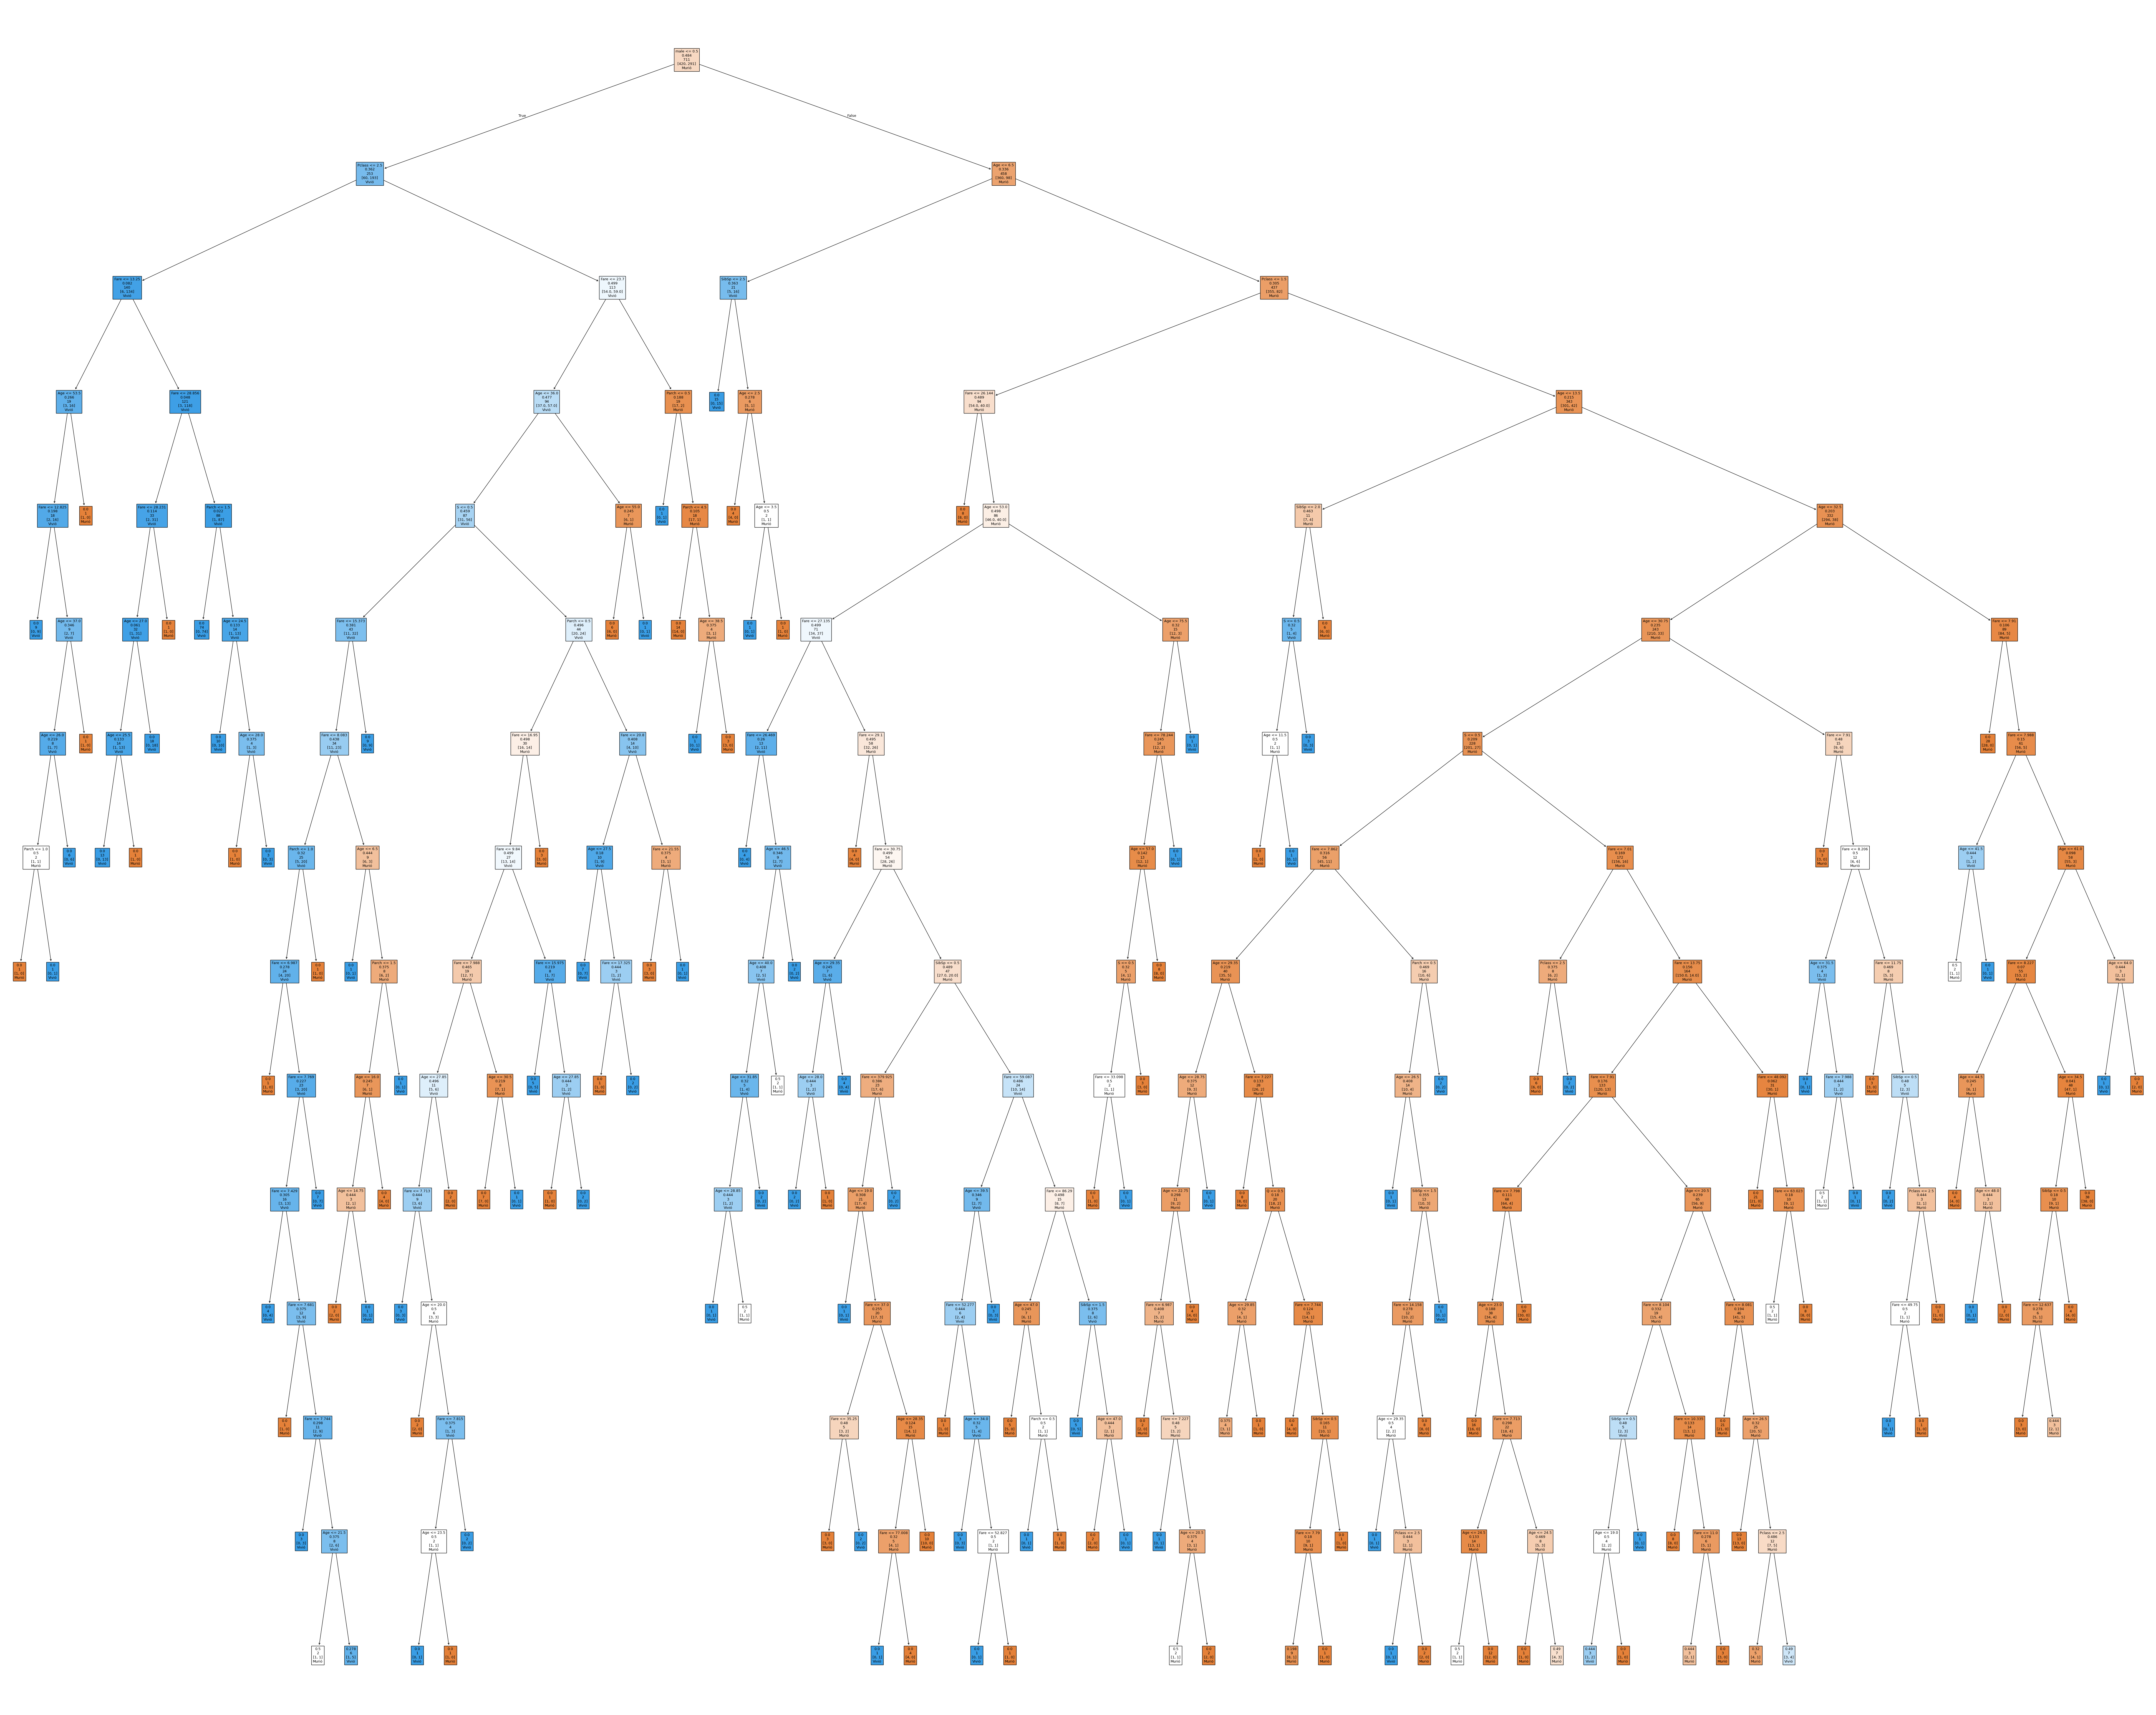

In [80]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(100,80))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=["Murió","Vivió"],
    filled=True, label="none"
)

## Reporte de clasificación final

Se presentan las métricas finales del modelo optimizado, incluyendo precisión, recall y F1-score.

In [37]:
from sklearn.metrics import classification_report

print (classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81       105
           1       0.76      0.62      0.68        73

    accuracy                           0.76       178
   macro avg       0.76      0.74      0.75       178
weighted avg       0.76      0.76      0.76       178



## Matriz de confusión final

Se analiza el desempeño final del modelo mediante la matriz de confusión, identificando aciertos y errores en la clasificación.

In [38]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[91, 14],
       [28, 45]])

In [39]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: si"])

,Pred: No,Pred: Si
Real: No,91,14
Real: si,28,45


# Predicción con nuevos datos

Se realiza una predicción con una nueva persona para determinar si sobreviviría o no.

In [40]:
nueva_presona = [1, 19, 0, 0, 100, 1, 0, 0]
perediccion = modelo.predict([nueva_presona])
if perediccion[0] ==1:
  print("Sobreviviste")
else:
  print("No Sobreviviste")

Sobreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
